In [35]:
import numpy as np 
from scipy.stats import norm
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import math

In [2]:
def call(S, K, T, r, sigma):
    if (T <= 0):
        return np.max(S - K, 0)
    if (sigma <= 0):
        return np.max(S - K, 0)
    d1 = (np.log(S / K) + r * T + sigma ** 2 * T / 2)/(sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def put(S, K, T, r, sigma):
    if T <= 0:
        return max(K - S, 0)
    if (sigma <= 0):
        return np.max(K - S, 0)
    d1 = (np.log(S / K) + r * T + sigma ** 2 * T / 2)/(sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def delta(S, K, T, r, sigma):
    d1 = (np.log(S / K) + r * T + sigma ** 2 * T / 2)/(sigma * np.sqrt(T))
    return norm.cdf(d1)

def vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + r * T + sigma ** 2 * T / 2)/(sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def gamma(S, K, T, r, sigma):
    d1 = (np.log(S / K) + r * T + sigma ** 2 * T / 2)/(sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def theta(S, K, T, r, sigma):
    d1 = (np.log(S / K) + r * T + sigma ** 2 * T / 2)/(sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)

def rho(S, K, T, r, sigma):
    d1 = (np.log(S / K) + r * T + sigma ** 2 * T / 2)/(sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * T * np.exp(-r * T) * norm.cdf(d2)

In [ ]:
"""
Newton-Raphson Method
Bisection Method
"""

"""
The price of an option is just price = f(S, K, T, r, sigma).
To find sigma, we need to solve the equation f(S, K, T, r, sigma) - market_price = 0.
That means that we need to find the roots of the equation. But because there is no direct function to find the roots, we need to use numerical methods.

"""


def implied_volatility(market_price, S, K, T, r, option_type='call', tol=1e-6, max_iter=100):
    sigma = math.sqrt((2 * math.pi) / T) * (market_price / S)     # Initial Guess (Manaster-Koehler seed for SPX)

    for i in range(max_iter):
        # If sigma leaves bounds, go to Bisection immediately
        if not (0.0001 < sigma < 5.0):
            return implied_volatility_bisection(market_price, S, K, T, r, sigma, option_type, tol, max_iter)
        
        if option_type == 'call':
            price = call(S, K, T, r, sigma)
        else:
            price = put(S, K, T, r, sigma)
            
        vega_value = vega(S, K, T, r, sigma)
        price_diff = price - market_price
        
        if abs(price_diff) < tol:
            return sigma
            
        # If Vega is too flat, go to Bisection
        if abs(vega_value) < 1e-10:
            return implied_volatility_bisection(market_price, S, K, T, r, sigma, option_type, tol, max_iter)
            
        sigma -= price_diff / vega_value

    # If no convergence, use  final guess to warm-start bisection
    return implied_volatility_bisection(market_price, S, K, T, r, sigma, option_type, tol, max_iter)


def implied_volatility_bisection(market_price, S, K, T, r, sigma_guess, option_type='call', tol=1e-6, max_iter=100):
    low = 0.0001
    high = 5.0
    
    # Warm start
    # Shrink search space to speed up bisection if Newton-Raphson guess is reasonable
    if 0.0001 < sigma_guess < 5.0:
        if option_type == 'call':
            price_at_guess = call(S, K, T, r, sigma_guess)
        else:
            price_at_guess = put(S, K, T, r, sigma_guess)
            
        if price_at_guess > market_price:
            high = sigma_guess  # Guess was too high, it becomes our new ceiling
        else:
            low = sigma_guess   # Guess was too low, it becomes our new floor

    # Normal Bisection
    for i in range(max_iter):
        mid = (low + high) / 2
        
        if option_type == 'call':
            price = call(S, K, T, r, mid)
        else:
            price = put(S, K, T, r, mid)
            
        if abs(price - market_price) < tol:
            return mid
        
        if price > market_price:
            high = mid
        else:
            low = mid
            
    return (low + high) / 2

In [ ]:
def option_chains(ticker):
    asset = yf.Ticker(ticker)
    expirations = asset.options
    
    # FETCH PRICE ONCE: Prevents loop bottlenecking
    history = asset.history(period="1d")
    if history.empty: return pd.DataFrame()
    S = history['Close'].iloc[-1]
    
    all_chains = []
    for expiration in expirations:
        opt = asset.option_chain(expiration)
        calls, puts = opt.calls.copy(), opt.puts.copy()
        calls['optionType'], puts['optionType'] = 'call', 'put'
        
        chain = pd.concat([calls, puts])
        chain['expiration'] = pd.to_datetime(expiration) + pd.DateOffset(hours=23, minutes=59)
        all_chains.append(chain)

    chains = pd.concat(all_chains).reset_index(drop=True)
    today = datetime.today()
    chains["daysToExpiration"] = (chains['expiration'] - today).dt.days + 1
    
    for index, row in chains.iterrows():
        # USE MID-PRICE: Match Yahoo Finance's IV basis
        mid = (row['bid'] + row['ask']) / 2
        market_price = mid if mid > 0 else row['lastPrice']
        
        # FILTER FOR OTM/ATM: Focus on stable time-value options
        # Skip deep ITM options where Vega is too low
        is_itm_call = (row['optionType'] == 'call' and row['strike'] < S * 0.98)
        is_itm_put = (row['optionType'] == 'put' and row['strike'] > S * 1.02)
        
        if is_itm_call or is_itm_put:
            # Setting to None ensures it doesn't break the plot later
            chains.at[index, "myImpliedVolatility"] = None
            continue

        K, T, r = row['strike'], row['daysToExpiration'] / 365.0, 0.045
        
        chains.at[index, "myImpliedVolatility"] = implied_volatility(
            market_price, S, K, T, r, row['optionType']
        )
        
    return chains
options_df = option_chains("SPY")

Plotting for expiration: 2026-03-02 23:59:00
Final rows to plot: 128


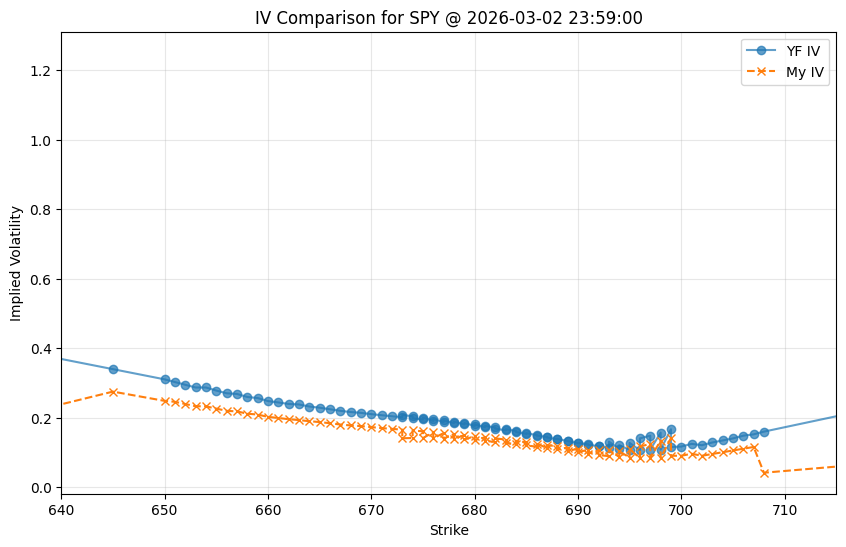

In [40]:
# 1. Fetch data
options_df = option_chains("SPY")

# 2. FAIL-SAFE: Pick the first expiration that actually has calculated data
# This prevents the "Hardcoded String" mismatch error
available_expiries = options_df.dropna(subset=["myImpliedVolatility"])["expiration"].unique()

if len(available_expiries) == 0:
    print("CRITICAL: No IVs were calculated in option_chains. Check your ITM filter logic.")
else:
    target_expiry = available_expiries[0] # Automatically pick the first valid date
    print(f"Plotting for expiration: {target_expiry}")

    # 3. Filter for this expiry and ensure numeric types
    plot_data = options_df[options_df["expiration"] == target_expiry].copy()
    plot_data["myImpliedVolatility"] = pd.to_numeric(plot_data["myImpliedVolatility"], errors='coerce')
    plot_data["impliedVolatility"] = pd.to_numeric(plot_data["impliedVolatility"], errors='coerce')

    # 4. Loosen the outlier filter
    # Drop rows missing either IV, then filter for a broader range (0.1% to 300%)
    plot_data = plot_data.dropna(subset=["myImpliedVolatility", "impliedVolatility"])
    plot_data = plot_data[(plot_data["myImpliedVolatility"] > 0.001) & (plot_data["myImpliedVolatility"] < 3.0)]

    print(f"Final rows to plot: {len(plot_data)}")

    if len(plot_data) < 2:
        print("Still not enough data. Try removing the ITM filter in option_chains entirely.")
    else:
        # 5. Generate Plots
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Plot both on the same axis to see the difference clearly
        data_sorted = plot_data.sort_values("strike")
        plt.plot(data_sorted["strike"], data_sorted["impliedVolatility"], label="YF IV", marker='o', alpha=0.7)
        plt.plot(data_sorted["strike"], data_sorted["myImpliedVolatility"], label="My IV", marker='x', linestyle='--')
        
        plt.title(f"IV Comparison for SPY @ {target_expiry}")
        plt.xlabel("Strike")
        plt.ylabel("Implied Volatility")
        plt.xlim(640, 715)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

In [44]:
# 1. Fetch data (ensure your option_chains function includes the OTM logic)
df = option_chains("SPY")

# 2. FORCE NUMERIC TYPES
# This prevents the TypeError from your previous screenshot
df["myImpliedVolatility"] = pd.to_numeric(df["myImpliedVolatility"], errors='coerce')
df["strike"] = pd.to_numeric(df["strike"], errors='coerce')
df["T_years"] = df["daysToExpiration"] / 365.0

# 3. FILTER FOR VALID PLOTTING DATA
# We drop the ITM 'None' values and filter out extreme calculation spikes 
surface_df = df.dropna(subset=["myImpliedVolatility"])
surface_df = surface_df[(surface_df["myImpliedVolatility"] > 0.001) & 
                        (surface_df["myImpliedVolatility"] < 1.5)]

print(f"Data points available for surface: {len(surface_df)}")

Data points available for surface: 4840


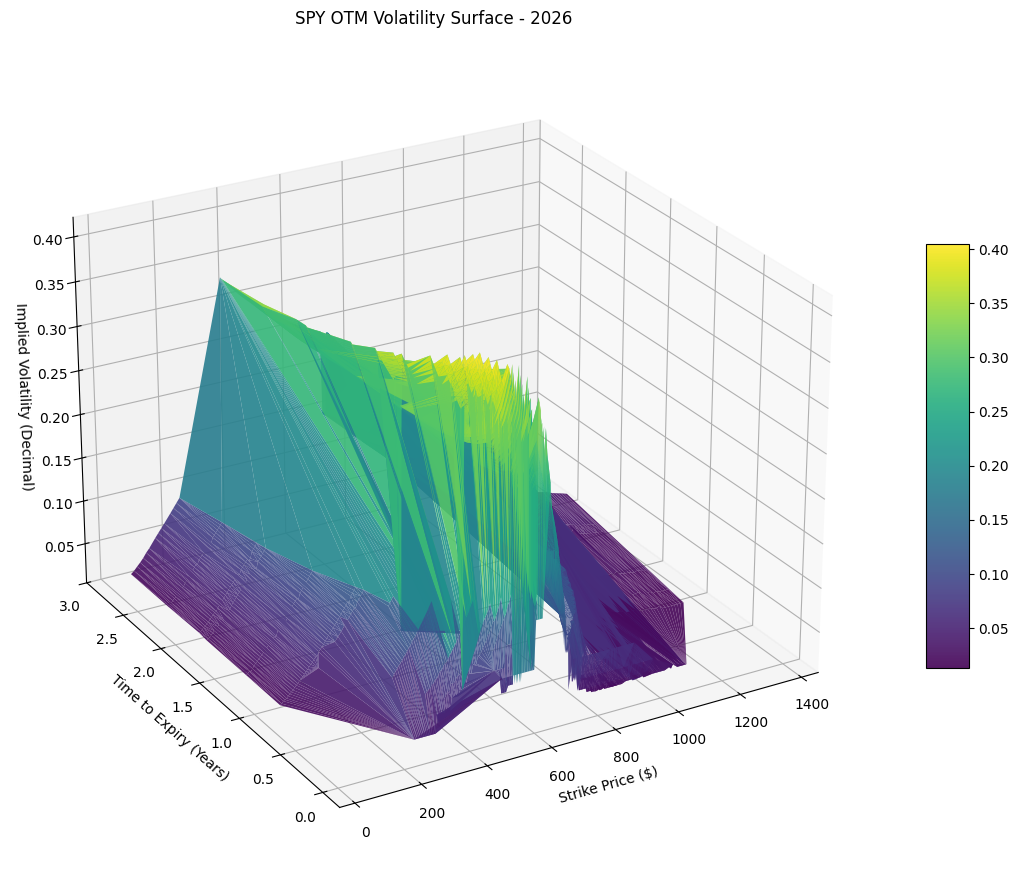

In [45]:
# Initialize the 3D Plot
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# Data axes
X = surface_df['strike']
Y = surface_df['T_years']
Z = surface_df['myImpliedVolatility']

# Create the surface mesh
# The viridis colormap helps visualize 'high vol' areas in yellow/green
surf = ax.plot_trisurf(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

# Labels and Aesthetics
ax.set_xlabel('Strike Price ($)')
ax.set_ylabel('Time to Expiry (Years)')
ax.set_zlabel('Implied Volatility (Decimal)')
ax.set_title('SPY OTM Volatility Surface - 2026')

# Add a color bar
fig.colorbar(surf, shrink=0.5, aspect=10)

# Set the view angle to clearly see the "Skew" (Strike) and "Term Structure" (Time)
ax.view_init(elev=25, azim=-120)

plt.tight_layout()
plt.show()

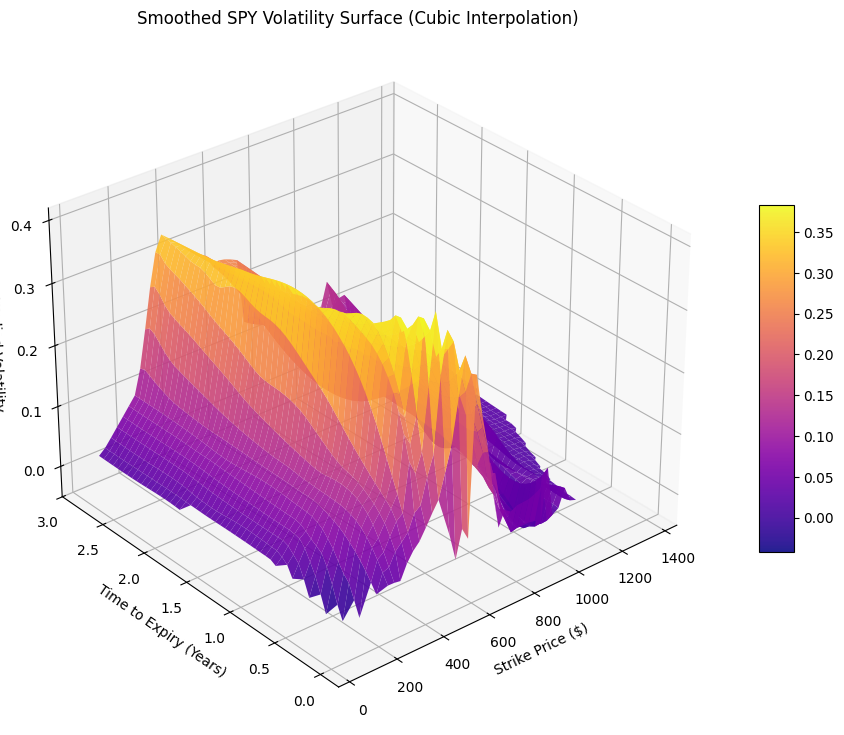

In [46]:
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# 1. Prepare and Clean Data
# Use the dataframe produced by your filtered option_chains logic
df_clean = df.dropna(subset=['myImpliedVolatility']).copy()
df_clean['myImpliedVolatility'] = pd.to_numeric(df_clean['myImpliedVolatility'], errors='coerce')

# Filter out extreme outliers that cause the 'spikes' seen in image_04a4a9
df_clean = df_clean[(df_clean['myImpliedVolatility'] > 0.02) & (df_clean['myImpliedVolatility'] < 1.0)]

# 2. Define the Grid
# Create a uniform range of strikes and times
strikes = np.linspace(df_clean['strike'].min(), df_clean['strike'].max(), 50)
times = np.linspace(df_clean['T_years'].min(), df_clean['T_years'].max(), 50)
strike_grid, time_grid = np.meshgrid(strikes, times)

# 3. Interpolate the scattered data onto the grid
# 'cubic' creates the smoothest surface; 'linear' is more rigid
grid_iv = griddata(
    (df_clean['strike'], df_clean['T_years']), 
    df_clean['myImpliedVolatility'], 
    (strike_grid, time_grid), 
    method='cubic'
)

# 4. Plot the Smoothed Surface
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with a colormap
surf = ax.plot_surface(strike_grid, time_grid, grid_iv, cmap='plasma', 
                       edgecolor='none', alpha=0.9, antialiased=True)

# Add Labels
ax.set_xlabel('Strike Price ($)')
ax.set_ylabel('Time to Expiry (Years)')
ax.set_zlabel('Implied Volatility')
ax.set_title('Smoothed SPY Volatility Surface (Cubic Interpolation)')

# Formatting
fig.colorbar(surf, shrink=0.5, aspect=10)
ax.view_init(elev=30, azim=-130)

plt.show()

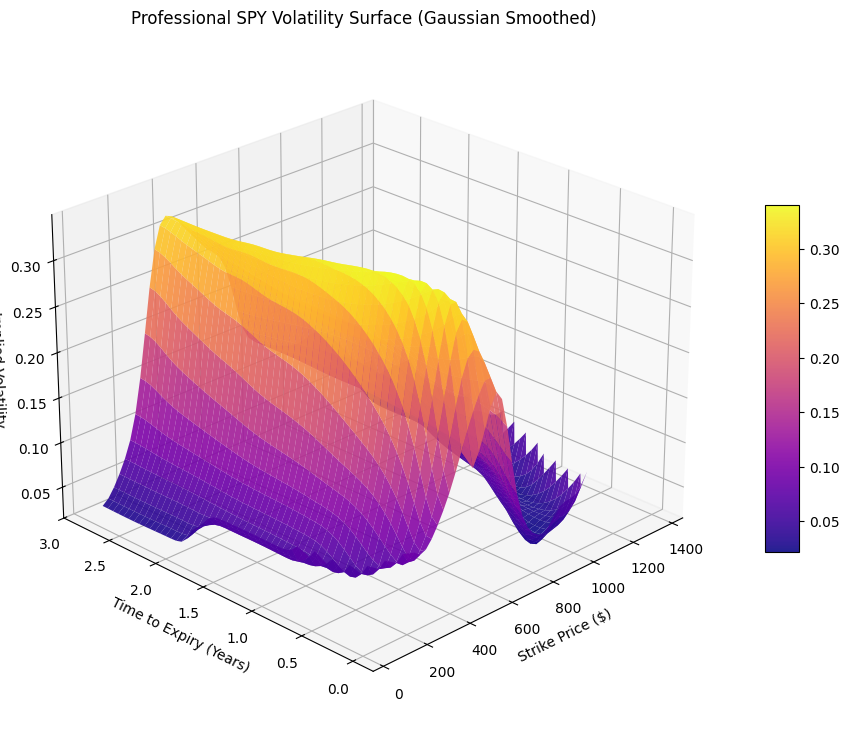

In [47]:
import numpy as np
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

# 1. PREPARE AND INTERPOLATE (as done previously)
df_clean = df.dropna(subset=['myImpliedVolatility']).copy()
df_clean = df_clean[(df_clean['myImpliedVolatility'] > 0.02) & (df_clean['myImpliedVolatility'] < 1.0)]

strikes = np.linspace(df_clean['strike'].min(), df_clean['strike'].max(), 50)
times = np.linspace(df_clean['T_years'].min(), df_clean['T_years'].max(), 50)
strike_grid, time_grid = np.meshgrid(strikes, times)

grid_iv = griddata(
    (df_clean['strike'], df_clean['T_years']), 
    df_clean['myImpliedVolatility'], 
    (strike_grid, time_grid), 
    method='cubic'
)

# 2. APPLY GAUSSIAN SMOOTHING
# Create a mask to remember where the 'real' data ends and the 'empty' grid begins
mask = np.isnan(grid_iv)

# Temporarily fill NaNs with the mean to prevent the filter from 'bleeding' black holes
grid_iv_filled = np.nan_to_num(grid_iv, nan=np.nanmean(grid_iv))

# Apply the filter. sigma=1.5 provides a moderate, professional-grade smoothing
smoothed_iv = gaussian_filter(grid_iv_filled, sigma=1.5)

# Restore the NaNs so the plot doesn't show fake data outside the actual market strikes
smoothed_iv[mask] = np.nan

# 3. PLOT THE FINAL SURFACE
fig, ax = plt.subplots(figsize=(14, 9), subplot_kw={"projection": "3d"})

surf = ax.plot_surface(strike_grid, time_grid, smoothed_iv, cmap='plasma', 
                       edgecolor='none', alpha=0.9, antialiased=True)

ax.set_xlabel('Strike Price ($)')
ax.set_ylabel('Time to Expiry (Years)')
ax.set_zlabel('Implied Volatility')
ax.set_title('Professional SPY Volatility Surface (Gaussian Smoothed)')

fig.colorbar(surf, shrink=0.5, aspect=10)
ax.view_init(elev=25, azim=-135)

plt.show()